# 基于 OpenCV 的人脸识别
本章节介绍如何使用 OpenCV 融合 ultraface-ncnn 来比对特征库，实现人脸识别功能。

## 例程
以下代码块可以直接运行：

1. 选中下面的代码块
2. 按 Shift + Enter 运行代码块
3. 观看实时视频窗口
4. 按 `STOP` 关闭实时视频，释放摄像头资源

### 如果运行时不能看到摄像头实时画面
- 需要点击上方的 Kernel - Shut down all kernels
- 关闭本章节选项卡，再次打开
- 点击 `STOP` 释放摄像头资源后重新运行代码块
- 重启设备

### 注意事项
如果使用CSI摄像头则需要注释`frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)`这一句。

### 与上一章节的区别
你可以更改 time_intervel 的数值来更改拍照的间隔时间，单位为秒。
你所拍摄的照片会被存储在/ugv_rpi/templates/media/pictures/文件夹内。

## 例程
以下代码块可以直接运行：

1. 选中下面的代码块
2. 按 Shift + Enter 运行代码块
3. 观看实时视频窗口
4. 按 `STOP` 关闭实时视频，释放摄像头资源

### 如果运行时不能看到摄像头实时画面
- 需要点击上方的 Kernel - Shut down all kernels
- 关闭本章节选项卡，再次打开
- 点击 `STOP` 释放摄像头资源后重新运行代码块
- 重启设备

### 本章节特性
当代码块正常运行时，你可以让机器人的摄像头对准人脸，观察画面中会自动圈出人脸所在的位置。

ToggleButton(value=False, button_style='danger', description='Stop', icon='square', tooltip='Description')

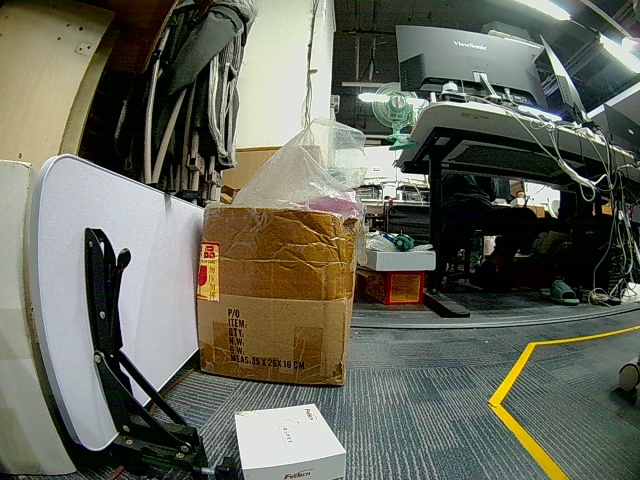

In [ ]:
import cv2  # 导入 OpenCV 库，用于图像处理
from picamera2 import Picamera2  # 用于访问 Raspberry Pi Camera 的库
import numpy as np  # 用于数学计算的库
from IPython.display import display, Image  # 用于在 Jupyter Notebook 中显示图像
import ipywidgets as widgets  # 用于创建交互式界面的小部件，如按钮
import threading  # 用于创建新线程，以便异步执行任务
from UltraFaceNcnn import UltraFaceNcnn

face_detector = UltraFaceNcnn('./ultraface-ncnn/RFB-320.param','./ultraface-ncnn/RFB-320.bin', input_size=(320,240), threshold=0.7, nms_threshold=0.3)

# 创建一个“停止”按钮，用户可以通过点击它来停止视频流
# ================
stopButton = widgets.ToggleButton(
    value=False,
    description='Stop',
    disabled=False,
    button_style='danger', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='Description',
    icon='square' # (FontAwesome names without the `fa-` prefix)
)


# 定义显示函数，用于处理视频帧并进行面部检测
# ================
def view(button):
    # 如果你使用的是CSI摄像头 需要取消注释 picam2 这些代码，并注释掉 camera 这些代码
    # 因为新版本的 OpenCV 不再支持 CSI 摄像头（4.9.0.80），你需要使用 picamera2 来获取摄像头画面
    
    # picam2 = Picamera2()  # 创建 Picamera2 的实例
    # picam2.configure(picam2.create_video_configuration(main={"format": 'XRGB8888', "size": (640, 480)}))  # 配置摄像头参数
    # picam2.start()  # 启动摄像头

    camera = cv2.VideoCapture(0) # 创建摄像头实例
    #设置分辨率
    camera.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    camera.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
    
    display_handle=display(None, display_id=True)  # 创建显示句柄用于更新显示的图像
    i = 0
    
    avg = None
    
    while True:
        # frame = picam2.capture_array()
        _, frame = camera.read() # 从摄像头捕获一帧图像
        # frame = cv2.flip(frame, 1) # if your camera reverses your image
        
        # 使用级联分类器进行面部检测
        faces = face_detector.detect(frame)

        if len(faces):
            for face in faces: # 遍历所有检测到的面部
                cv2.rectangle(frame,(int(face.x1),int(face.y1)),(int(face.x2),int(face.y2)),(64,128,255),1)

        _, frame = cv2.imencode('.jpeg', frame) # 将帧编码为 JPEG 格式
        display_handle.update(Image(data=frame.tobytes()))
        if stopButton.value==True:
            # picam2.close() # 如果是，则关闭摄像头
            camera.release() # 如果是，则关闭摄像头
            display_handle.update(None)

            
# 显示“停止”按钮并启动显示函数的线程
# ================
display(stopButton)
thread = threading.Thread(target=view, args=(stopButton,))
thread.start()